# Option A: Interactive regional trends (CSV-based)

This notebook loads the generated CSVs in `outputs/tables/` and provides a lightweight, notebook-native way to explore regional trends and state-level prevalence. It reuses existing outputs and stays read-only with respect to the source data.


## 1) Environment setup
- Imports standard libraries (pandas, matplotlib, pathlib)
- Tries to import `ipywidgets` for dropdown controls (falls back to manual invocation if unavailable)
- Locates the project root and the `outputs/tables` directory


In [1]:
# Imports and paths
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    widgets = None
    warnings.warn("ipywidgets not installed; dropdown UI will be skipped. Install with `pip install ipywidgets`.", UserWarning)


def locate_tables_dir() -> Path:
    """Resolve the outputs/tables directory whether run from repo root or notebooks/."""
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "outputs" / "tables",
        cwd.parent / "outputs" / "tables",
    ]
    for cand in candidates:
        if cand.exists():
            return cand
    raise FileNotFoundError("Could not find outputs/tables. Run the regional runner first to generate CSVs.")


tables_dir = locate_tables_dir()
tables_dir

PosixPath('/Users/aryanthodupunuri/RegionalVitals/outputs/tables')

## 2) Implement logic
Functions to discover available region/measure pairs, load data, and render charts/tables. Uses matplotlib for plots; widgets are optional.


In [2]:
def discover_combos(dir_path: Path):
    combos = []
    for p in dir_path.glob("*_regional_trends.csv"):
        parts = p.stem.split("_")
        # Expect pattern: {region}_{measure}_regional_trends
        if len(parts) < 3:
            continue
        region = parts[0]
        measure = "_".join(parts[1:-2])
        combos.append((region, measure))
    # unique and sorted
    return sorted(set(combos), key=lambda x: (x[0], x[1]))


def load_data(region: str, measure: str):
    reg_file = tables_dir / f"{region.lower()}_{measure.lower()}_regional_trends.csv"
    state_file = tables_dir / f"{region.lower()}_{measure.lower()}_state_prevalence.csv"
    if not reg_file.exists() or not state_file.exists():
        raise FileNotFoundError(f"Missing files for region={region}, measure={measure}. Run the runner first.")
    reg = pd.read_csv(reg_file)
    state = pd.read_csv(state_file)
    return reg, state


def plot_regional_trend(df_regional: pd.DataFrame, region: str, measure: str):
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.plot(df_regional["year"], df_regional["prevalence_pct"], marker="o", color="#1f77b4")
    ax.set_title(f"{region} — {measure} (regional weighted prevalence)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Prevalence (%)")
    ax.grid(True, alpha=0.3)
    plt.show()


def plot_state_lines(df_state: pd.DataFrame, region: str, measure: str):
    fig, ax = plt.subplots(figsize=(9, 5))
    for state, group in df_state.groupby("state"):
        ax.plot(group["year"], group["prevalence_pct"], label=state, alpha=0.35)
    ax.set_title(f"{region} — {measure} by state")
    ax.set_xlabel("Year")
    ax.set_ylabel("Prevalence (%)")
    ax.grid(True, alpha=0.3)
    # Light legend for readability
    ax.legend(ncol=4, fontsize=8, frameon=False)
    plt.show()


def render(region: str, measure: str):
    region_norm = region.strip()
    measure_norm = measure.strip()
    reg, state = load_data(region_norm, measure_norm)
    print(f"Loaded {len(reg)} regional rows and {len(state)} state rows for region={region_norm}, measure={measure_norm}.")
    plot_regional_trend(reg, region_norm, measure_norm)
    plot_state_lines(state, region_norm, measure_norm)
    display(state.head())


combos = discover_combos(tables_dir)
print(f"Found {len(combos)} region/measure combinations:", combos)

Found 1 region/measure combinations: [('west', 'obesity')]


## 3) Validation and testing
Lightweight checks to ensure the outputs directory exists and at least one region/measure pair is discoverable.


In [3]:
# Basic validation
assert tables_dir.exists(), "outputs/tables does not exist"
if len(combos) == 0:
    warnings.warn("No region/measure outputs found. Run the regional runner to generate CSVs.")
else:
    sample_region, sample_measure = combos[0]
    print(f"Sample combo: region={sample_region}, measure={sample_measure}")
    # Quick schema check
    reg_df, state_df = load_data(sample_region, sample_measure)
    required_reg_cols = {"region", "year", "measure", "prevalence_pct"}
    required_state_cols = {"year", "state", "measure", "prevalence_pct"}
    assert required_reg_cols.issubset(reg_df.columns), "Regional trends missing columns"
    assert required_state_cols.issubset(state_df.columns), "State prevalence missing columns"
    print("Validation passed for sample combo.")

Sample combo: region=west, measure=obesity
Validation passed for sample combo.


## 4) Execution and outputs
Use the dropdown (if `ipywidgets` is available) or call `render(region, measure)` manually. Plots will appear below.


Dropdown(description='Combo', options=(('West — obesity', ('west', 'obesity')),), value=('west', 'obesity'))

Loaded 13 regional rows and 143 state rows for region=west, measure=obesity.


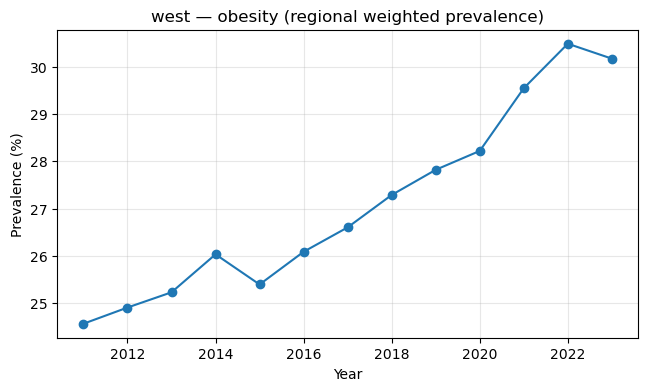

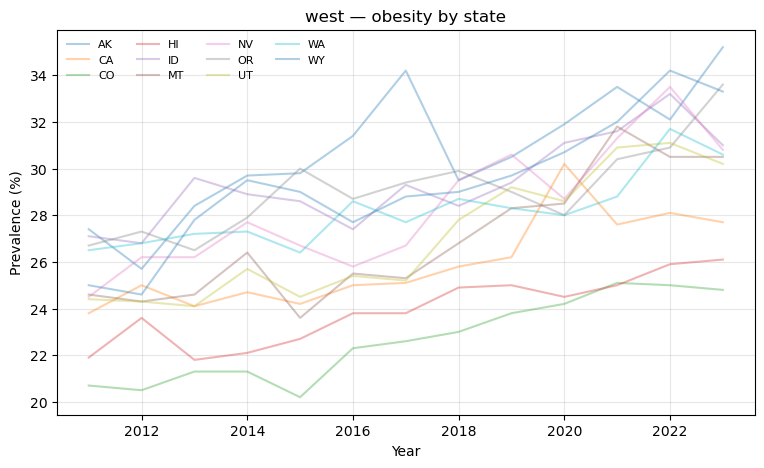

,year,state,measure,prevalence_pct,sample_size
0,2011,AK,obesity,27.4,950
1,2011,CA,obesity,23.8,3971
2,2011,CO,obesity,20.7,2732
3,2011,HI,obesity,21.9,1538
4,2011,ID,obesity,27.1,1570


In [4]:
def show_ui():
    if len(combos) == 0:
        print("No outputs found. Please generate CSVs with the regional runner first.")
        return
    if HAS_WIDGETS:
        options = [(f"{r.title()} — {m}", (r, m)) for r, m in combos]
        dropdown = widgets.Dropdown(options=options, description="Combo")

        def _on_change(change):
            if change["name"] == "value" and change["new"] is not None:
                r, m = change["new"]
                render(r, m)

        dropdown.observe(_on_change, names="value")
        display(dropdown)
        # initial render
        render(*dropdown.value)
    else:
        print("ipywidgets not installed. To enable dropdown UI, run `pip install ipywidgets`.\n"
              "Alternatively, call `render(region, measure)` manually, e.g.:\n"
              "render('West', 'obesity')")


show_ui()